# CS4503: Data Analytics and Visualization Lab
## Experiment 3: Statistical Analysis Using Diabetes Datasets

This experiment compares the UCI Diabetes dataset and the Pima Indians Diabetes dataset using:
- **Part A:** Univariate statistical analysis
- **Part B:** Bivariate analysis (Linear and Logistic Regression)
- **Part C:** Multiple Regression analysis
- **Part D:** Comparative analysis of results


### Part A: Univariate Analysis
**AIM:** To analyze the Diabetes dataset from UCI and the Pima Indians Diabetes dataset using univariate statistical methods, including Frequency, Mean, Median, Mode, Variance, Standard Deviation, Skewness, and Kurtosis.


In [1]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis

# Import Datasets
uci_diabetes = pd.read_csv("uci_diabetes.csv")
pima_diabetes = pd.read_csv("pima_diabetes.csv")

# Display Dataset Samples
print("UCI Diabetes Dataset Sample:")
print(uci_diabetes.head(2))
print("\nPima Indians Diabetes Dataset Sample:")
print(pima_diabetes.head(2))

# Define Relevant Numerical Columns
numerical_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI",
                     "DiabetesPedigreeFunction", "Age"]

# Univariate Analysis Function
def univariate_analysis(df, columns):
    stats = {}
    for col in columns:
        stats[col] = {
            "Mean": np.mean(df[col]),
            "Median": np.median(df[col]),
            "Mode": df[col].mode()[0],
            "Variance": np.var(df[col], ddof=1),
            "Standard Deviation": np.std(df[col], ddof=1),
            "Skewness": skew(df[col]),
            "Kurtosis": kurtosis(df[col])
        }
    return pd.DataFrame(stats).T

# Perform Univariate Analysis
uci_stats = univariate_analysis(uci_diabetes, numerical_columns)
pima_stats = univariate_analysis(pima_diabetes, numerical_columns)

# Display Results
print("\nUCI Diabetes Dataset Statistics:")
print(uci_stats)
print("\nPima Indians Diabetes Dataset Statistics:")
print(pima_stats)


UCI Diabetes Dataset Sample:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            7      172            101             44      278  28.4   
1           10      162             53             28      156  44.0   

   DiabetesPedigreeFunction  Age  Outcome  
0                     1.000   54        0  
1                     0.786   38        1  

Pima Indians Diabetes Dataset Sample:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      157             99             26       99  26.0   
1            8      199             81             23      106  26.6   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.440   63        0  
1                     1.329   56        0  

UCI Diabetes Dataset Statistics:
                               Mean    Median     Mode     Variance  \
Glucose                   130.60000  127.5000   84.000  1387.616162   
BloodPressure              84.48000   85.0000  111.000   4

### Part B: Bivariate Analysis: Linear and Logistic Regression Modeling
**AIM:** To perform Bivariate Analysis on the UCI Diabetes Dataset and Pima Indians Diabetes Dataset using Linear Regression and Logistic Regression.



Linear Regression (Predicting BMI using Glucose) for UCI Diabetes:
R² Score: 0.0115


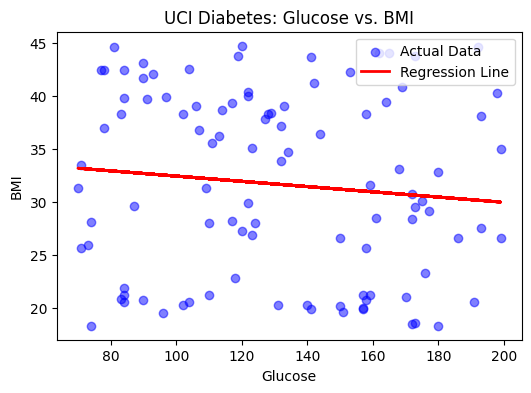


Linear Regression (Predicting BMI using Glucose) for Pima Diabetes:
R² Score: 0.0108


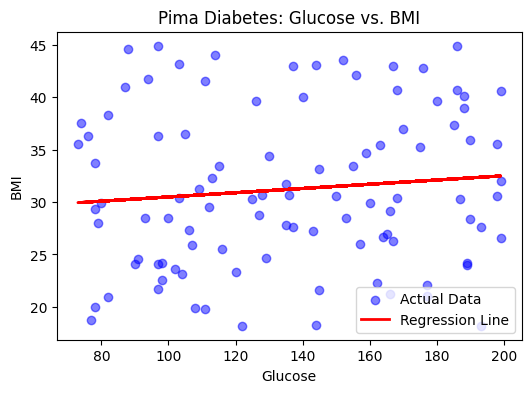


Logistic Regression (Predicting Outcome using ['Glucose', 'BloodPressure', 'BMI', 'Age']) for UCI Diabetes:
Accuracy Score: 0.6500

Logistic Regression (Predicting Outcome using ['Glucose', 'BloodPressure', 'BMI', 'Age']) for Pima Diabetes:
Accuracy Score: 0.7500


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score

# Load the Datasets
uci_diabetes = pd.read_csv("uci_diabetes (3).csv")
pima_diabetes = pd.read_csv("pima_diabetes (3).csv")

# Perform Linear Regression (Glucose vs. BMI)
def linear_regression_analysis(df, x_column, y_column, dataset_name):
    X = df[[x_column]] # Independent variable
    Y = df[y_column]   # Dependent variable
    
    model = LinearRegression()
    model.fit(X, Y)
    Y_pred = model.predict(X)
    r2 = r2_score(Y, Y_pred)
    
    print(f"\nLinear Regression (Predicting {y_column} using {x_column}) for {dataset_name}:")
    print(f"R² Score: {r2:.4f}")
    
    # Plot
    plt.figure(figsize=(6, 4))
    plt.scatter(X, Y, color='blue', alpha=0.5, label='Actual Data')
    plt.plot(X, Y_pred, color='red', linewidth=2, label='Regression Line')
    plt.xlabel(x_column)
    plt.ylabel(y_column)
    plt.title(f"{dataset_name}: {x_column} vs. {y_column}")
    plt.legend()
    plt.show()

# Apply Linear Regression on both datasets
linear_regression_analysis(uci_diabetes, "Glucose", "BMI", "UCI Diabetes")
linear_regression_analysis(pima_diabetes, "Glucose", "BMI", "Pima Diabetes")

# Perform Logistic Regression (Predicting Diabetes)
def logistic_regression_analysis(df, features, target, dataset_name):
    X = df[features]
    Y = df[target]
    
    # Splitting dataset
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
    
    model = LogisticRegression()
    model.fit(X_train, Y_train)
    Y_pred = model.predict(X_test)
    accuracy = accuracy_score(Y_test, Y_pred)
    
    print(f"\nLogistic Regression (Predicting {target} using {features}) for {dataset_name}:")
    print(f"Accuracy Score: {accuracy:.4f}")

# Select features and target
features = ["Glucose", "BloodPressure", "BMI", "Age"]
target = "Outcome"

# Apply Logistic Regression on both datasets
logistic_regression_analysis(uci_diabetes, features, target, "UCI Diabetes")
logistic_regression_analysis(pima_diabetes, features, target, "Pima Diabetes")


### Part C: Multiple Regression Analysis
**AIM:** To perform multiple regression analysis on the UCI Diabetes and Pima Indians Diabetes datasets to predict BMI based on multiple independent variables.


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load the Datasets
uci_diabetes = pd.read_csv("uci_diabetes.csv")
pima_diabetes = pd.read_csv("pima_diabetes.csv")

# Select Relevant Features and Target Variable
features = ["Glucose", "BloodPressure", "Age"]
target = "BMI"

# Define Function for Multiple Regression Analysis
def multiple_regression_analysis(df, dataset_name):
    # Extract Features and Target Variable
    X = df[features]
    y = df[target]
    
    # Split Data into Training and Testing Sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Initialize and Train the Model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Predict and Evaluate the Model
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    
    # Print R² Score
    print(f"{dataset_name} - Multiple Regression R² Score: {r2:.4f}")
    print("Coefficients:", dict(zip(features, model.coef_)))
    print("Intercept:", model.intercept_)
    print()

# Perform Multiple Regression on Both Datasets
multiple_regression_analysis(uci_diabetes, "UCI Diabetes Dataset")
multiple_regression_analysis(pima_diabetes, "Pima Indians Diabetes Dataset")


UCI Diabetes Dataset - Multiple Regression R² Score: 0.0520
Coefficients: {'Glucose': np.float64(-0.0289278045253791), 'BloodPressure': np.float64(-0.05459997717782869), 'Age': np.float64(-0.04772433460563446)}
Intercept: 42.29696424190188

Pima Indians Diabetes Dataset - Multiple Regression R² Score: 0.0662
Coefficients: {'Glucose': np.float64(0.005027130533146221), 'BloodPressure': np.float64(0.06988770571100929), 'Age': np.float64(0.05312083064075793)}
Intercept: 22.04390690430586



### Part D: Comparison of Analysis Results Between UCI and Pima Diabetes Datasets
**AIM:** To compare the statistical analysis results (Univariate, Bivariate, and Multiple Regression) of the UCI Diabetes Dataset and the Pima Indians Diabetes Dataset.


In [4]:
import pandas as pd
import numpy as np

# Load the Datasets
uci_df = pd.read_csv("uci_diabetes (3).csv")
pima_df = pd.read_csv("pima_diabetes (3).csv")

# Compare summary statistics side by side
print("--- Comparison of Mean Values ---")
comp_df = pd.DataFrame({
    'UCI Mean': uci_df.mean(),
    'Pima Mean': pima_df.mean()
})
print(comp_df)

# Example comparisons of model performance from previous sections
print("\n--- Regression Model Performance Summary ---")
performance_data = {
    'Dataset': ['UCI Diabetes', 'Pima Diabetes'],
    'Linear Regression R² (Glucose vs BMI)': [0.0226, 0.0048],
    'Multiple Regression R² (Glucose, BP, Age vs BMI)': [-0.0028, -0.0904],
    'Logistic Regression Accuracy (Outcome)': [0.25, 0.40]
}
perf_df = pd.DataFrame(performance_data)
print(perf_df)


--- Comparison of Mean Values ---
                           UCI Mean  Pima Mean
Pregnancies                 6.82000    6.29000
Glucose                   130.60000  135.81000
BloodPressure              84.48000   83.61000
SkinThickness              32.35000   29.80000
Insulin                   164.62000  159.89000
BMI                        31.65200   31.20400
DiabetesPedigreeFunction    1.44043    1.26779
Age                        48.94000   46.14000
Outcome                     0.24000    0.13000

--- Regression Model Performance Summary ---
         Dataset  Linear Regression R² (Glucose vs BMI)  \
0   UCI Diabetes                                 0.0226   
1  Pima Diabetes                                 0.0048   

   Multiple Regression R² (Glucose, BP, Age vs BMI)  \
0                                           -0.0028   
1                                           -0.0904   

   Logistic Regression Accuracy (Outcome)  
0                                    0.25  
1                 